# Quantitative Evaluation of Explainable Dueling Deep Reinforcement Learning (PPO) in Dairy Supply Chain Optimization


## Setup Device


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Ignore Warning


In [2]:
import warnings

warnings.filterwarnings("ignore")

## Creating plots Directory


In [3]:
from pathlib import Path

# Define your directory path
dir_path = Path("./plots")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

# Define your directory path
dir_path = Path("./results")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

## Research-Grade Visualization


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Load Data


In [5]:
import os
import kagglehub
import pandas as pd

print("Loading data...")
path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
data_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_path)
print("Data loading was successful...")

Loading data...
Data loading was successful...


In [6]:
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_cols}")

Rows: 122983
Columns: 24


## Environment Formulation & Offline Data Engineering


### Temporal Feature Engineering


In [7]:
print("Processing temporal features...")

# Convert date columns to datetime objects dates are in DD-MM-YYYY format
date_cols = ["Date", "Production Date", "Expiration Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

# Calculate 'Days to Expiration'
# This is the exact number of days left from the current transaction 'Date' until the product spoils.
df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days

# Drop rows where expiration is negative (already spoiled before the record date) or where dates are missing due to parsing errors.
df = df[df["Days_to_Expiration"] >= 0].copy()

# Calculate Age of product since production
df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

print("Processing temporal features was successful...")

Processing temporal features...
Processing temporal features was successful...


#### Age-Structured Inventory Matrix (FIFO)


In [8]:
print("Building FIFO age-structured matrices...")
# In Deep RL, the agent needs a fixed-size vector to understand inventory age.
# We will create a vector up to 'MAX_SHELF_LIFE' (e.g., 30 days).
# Bins: [Expiring in 0-2 days, 3-5 days, ..., 20+ days]

MAX_SHELF_LIFE = 30  # Cap for the maximum days we track individually

# Pivot the data to create a state vector for each Product ID on each Date
# We group by Date and Product ID, and sum the Quantity in Stock for each expiration day.
fifo_matrix = df.pivot_table(
    index=["Date", "Product ID"],
    columns="Days_to_Expiration",
    values="Quantity in Stock (liters/kg)",
    aggfunc="sum",
    fill_value=0,
)

# Truncate and group columns beyond MAX_SHELF_LIFE to prevent infinite state space expansion
cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]

if cols_to_group:
    fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
    fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

# Rename columns for clarity in the RL State Vector
fifo_matrix.columns = [
    f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
    for col in fifo_matrix.columns
]

print(f"Created FIFO matrix with shape: {fifo_matrix.shape}")
# You can merge this back into your main environment dataframe using the Date and Product ID indices.

Building FIFO age-structured matrices...
Created FIFO matrix with shape: (56546, 32)


#### Multicollinearity Detection


In [9]:
import numpy as np

print("Analyzing Multicollinearity for XAI ROAR/PI evaluation...")

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr().abs()

# Create a mask to ignore the diagonal and the lower triangle (to avoid duplicate pairs)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Set a threshold for identifying highly collinear features
COLLINEAR_THRESHOLD = 0.85

# Find index pairs with correlation above the threshold
collinear_pairs = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i + 1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > COLLINEAR_THRESHOLD
]

print(f"\nHighly Collinear Feature Pairs (Threshold > {COLLINEAR_THRESHOLD}):")

for feat1, feat2, corr_val in collinear_pairs:
    print(f"[{corr_val:.3f}] {feat1} <--> {feat2}")

Analyzing Multicollinearity for XAI ROAR/PI evaluation...

Highly Collinear Feature Pairs (Threshold > 0.85):
[0.988] Price per Unit <--> Price per Unit (sold)


### State & Action Formulation


#### Create the RL Environment DataFrame


In [10]:
# Merge FIFO into main dataframe to create the raw RL Environment DataFrame
rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")

# Fill NaNs with 0 for days where no stock is expiring in that specific bin
rl_df.fillna(0, inplace=True)

# Shape of the RL Environment dataframe
print("Shape:", rl_df.shape)

Shape: (60035, 58)


#### Encode Categorical Variables


In [11]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Neural networks require numeric inputs. We encode string categories into integers.
print("Encoding categorical variables...")
categorical_cols = [
    "Location",
    "Farm Size",
    "Product Name",
    "Brand",
    "Storage Condition",
    "Sales Channel",
]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    rl_df[col] = le.fit_transform(rl_df[col].astype(str))
    encoders[col] = le

# Save encoders for later decoding during XAI rule extraction
# Path("./model").mkdir(parents=True, exist_ok=True)
# joblib.dump(encoders, "./model/PPO_categorical_encoders.pkl")

Encoding categorical variables...


#### Define State (S) Features


In [12]:
# The state represents the "observation" the agent sees before making a decision.
# We explicitly exclude 'Approx. Total Revenue' and 'Quantity Sold' because these are the outcome (Reward components) that happen after the action is taken.
state_cols = [
    "Location",
    "Total Land Area (acres)",
    "Number of Cows",
    "Farm Size",
    "Product ID",
    "Product Name",
    "Brand",
    "Shelf Life (days)",
    "Storage Condition",
    "Quantity in Stock (liters/kg)",
    "Minimum Stock Threshold (liters/kg)",
    "Price per Unit",  # Base cost (Environmental constraint)
    "Days_to_Expiration",
    "Product_Age_Days",
] + list(fifo_matrix.columns)  # Append the dynamic age-structured inventory

print(f"State vector comprises {len(state_cols)} dimensions.")

State vector comprises 46 dimensions.


#### Define Action (A) Features


In [13]:
# As modeled in the literature, we use a continuous action space controlling dynamic pricing and inventory simultaneously.
action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]
print(f"Action vector comprises {len(action_cols)} dimensions.")

Action vector comprises 2 dimensions.


#### Extract and Scale the Matrices


In [14]:
# Deep RL algorithms (like PPO or Continuous DQN) require standardized inputs (Mean=0, Std=1) to prevent exploding gradients and ensure stable convergence.
print("\nScaling State and Action matrices...")
scaler_S = StandardScaler()
scaler_A = StandardScaler()  # Useful if actions are continuously bounded

# Extract raw matrices
S_raw = rl_df[state_cols].values
A_raw = rl_df[action_cols].values

# Fit and transform
S_matrix = scaler_S.fit_transform(S_raw)
A_matrix = scaler_A.fit_transform(A_raw)

print(f"-> State Space (S) shape: {S_matrix.shape}")
print(f"-> Action Space (A) shape: {A_matrix.shape}")

# Store the final dataframe for the Reward engineering step
rl_df_final = rl_df.copy()

print("\nState and Action formulation completed successfully.")


Scaling State and Action matrices...
-> State Space (S) shape: (60035, 46)
-> Action Space (A) shape: (60035, 2)

State and Action formulation completed successfully.


### Reward Engineering & Shaping


In [15]:
df_reward = rl_df_final.copy()

#### Base Financial Sub-Rewards (Multi-Objective Decomposition)


In [16]:
print("Calculating financial sub-rewards...")

# A. Gross Profit: Revenue minus the baseline cost of the goods sold
rl_df_final["Gross_Profit"] = rl_df_final["Approx. Total Revenue(INR)"] - (
    rl_df_final["Quantity Sold (liters/kg)"] * rl_df_final["Price per Unit"]
)

# B. Waste Penalty: Heavily penalize items that expire immediately (0 or 1 days left)
# We apply a 150% penalty to account for the lost cost of the item plus disposal logistics.
waste_col = (
    "Stock_Expiring_in_0_Days"
    if "Stock_Expiring_in_0_Days" in rl_df_final.columns
    else "Stock_Expiring_in_1_Days"
)
rl_df_final["Waste_Penalty"] = (
    rl_df_final[waste_col] * rl_df_final["Price per Unit"] * 1.5
)

# C. Holding Cost: The operational cost of storing the current inventory (Assumed 5% of unit cost)
rl_df_final["Holding_Cost"] = (
    rl_df_final["Quantity in Stock (liters/kg)"] * rl_df_final["Price per Unit"] * 0.05
)

# D. Stockout Penalty (Potential-based heuristic):
# Severe penalty for allowing stock to drop below the Minimum Stock Threshold.
rl_df_final["Stockout_Penalty"] = np.where(
    rl_df_final["Quantity in Stock (liters/kg)"]
    < rl_df_final["Minimum Stock Threshold (liters/kg)"],
    (
        rl_df_final["Minimum Stock Threshold (liters/kg)"]
        - rl_df_final["Quantity in Stock (liters/kg)"]
    )
    * rl_df_final["Price per Unit"]
    * 2.0,
    0,
)

print("Calculating financial sub-rewards successfully...")

Calculating financial sub-rewards...
Calculating financial sub-rewards successfully...


#### Aggregating the Raw Reward


In [17]:
print("Aggregating Raw Reward...")
rl_df_final["Raw_Reward"] = (
    rl_df_final["Gross_Profit"]
    - rl_df_final["Waste_Penalty"]
    - rl_df_final["Holding_Cost"]
    - rl_df_final["Stockout_Penalty"]
)
print("Aggregating Raw Reward successfully...")

Aggregating Raw Reward...
Aggregating Raw Reward successfully...


#### Preference As Reward (PAR) Bounding


In [18]:
print("Applying Preference As Reward (PAR) bounding...")
# Unbounded rewards cause gradient explosion in Actor-Critic models.
# We use a Sigmoid function to center and bound the rewards strictly between -1 and 1.

# Establish the dataset's baseline reference points
r_median = rl_df_final["Raw_Reward"].median()
r_std = rl_df_final["Raw_Reward"].std()


def par_transform(r, ref, std, k=2.0):
    """
    Applies sigmoid bounding.
    k controls the steepness of the reward curve.
    """
    return 2 / (1 + np.exp(-k * (r - ref) / std)) - 1


# Apply the transformation
rl_df_final["Bounded_Reward_PAR"] = par_transform(
    rl_df_final["Raw_Reward"], r_median, r_std
)

print("Applying Preference As Reward (PAR) bounding successfully...")

Applying Preference As Reward (PAR) bounding...
Applying Preference As Reward (PAR) bounding successfully...


#### Extract Final MDP Arrays for Training


In [19]:
# The Reward array (R)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values

print("\nReward Summary Statistics:")
print(rl_df_final[["Raw_Reward", "Bounded_Reward_PAR"]].describe())

print(f"\n-> Reward Space (R) shape: {R_matrix.shape}")


Reward Summary Statistics:
          Raw_Reward  Bounded_Reward_PAR
count   60035.000000        60035.000000
mean    -2024.795992           -0.048919
std      7576.005953            0.492767
min   -149276.123916           -1.000000
25%     -4334.923495           -0.390078
50%     -1214.426635            0.000000
75%       716.080589            0.249443
max     60077.369805            1.000000

-> Reward Space (R) shape: (60035,)


## Deep RL Surrogate Training (Offline)


### Replay Buffer Initialization & Transition Engineering


#### Temporal Transition Engineering (S, A, R, S')


In [20]:
print("Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...")

# To get the "Next State" (S_t+1), we must sort the dataframe chronologically for each specific Product and Location.
rl_df_final = rl_df_final.sort_values(
    by=["Location", "Product ID", "Date"]
).reset_index(drop=True)

# Re-extract the matrices from the Sorted dataframe to ensure temporal alignment
S_raw = rl_df_final[state_cols].values
A_matrix = scaler_A.transform(rl_df_final[action_cols].values)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values
S_matrix = scaler_S.transform(S_raw)

# Calculate Next State (S_t+1) by shifting the state matrix by 1
S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)

# Identify Terminal States (Done flags)
# A state is terminal if the next row belongs to a different Product or different Location
is_terminal = (
    (rl_df_final["Product ID"] != rl_df_final["Product ID"].shift(-1))
    | (rl_df_final["Location"] != rl_df_final["Location"].shift(-1))
).values.copy()

# The last row of the entire dataset is always terminal
is_terminal[-1] = True

print(f"Extracted {len(S_matrix)} total transitions.")
print(f"Identified {is_terminal.sum()} terminal states (Episode boundaries).")

Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...
Extracted 60035 total transitions.
Identified 54196 terminal states (Episode boundaries).


#### Prioritized Experience Replay (PER)


In [21]:
import torch

print("Initializing Offline Prioritized Experience Replay (PER) Buffer...")


class OfflinePrioritizedReplayBuffer:
    def __init__(
        self, states, actions, rewards, next_states, dones, alpha=0.6, beta=0.4
    ):
        """
        Initializes the PER buffer with pre-collected offline data.
        alpha: Determines how much prioritization is used (0 = uniform, 1 = full priority)
        beta: Importance Sampling (IS) weight factor (0 = no correction, 1 = full correction)
        """
        self.size = len(states)
        self.states = torch.tensor(states.copy(), dtype=torch.float32)
        self.actions = torch.tensor(actions.copy(), dtype=torch.float32)
        self.rewards = torch.tensor(rewards.copy(), dtype=torch.float32).unsqueeze(1)
        self.next_states = torch.tensor(next_states.copy(), dtype=torch.float32)
        self.dones = torch.tensor(dones.copy(), dtype=torch.float32).unsqueeze(1)

        self.alpha = alpha
        self.beta = beta

        # Initialize priorities to maximum (1.0) so all transitions are sampled at least once initially
        self.priorities = np.ones(self.size, dtype=np.float32)

    def sample(self, batch_size):
        """
        Samples a batch of transitions based on priority probabilities.
        """
        # Calculate probability distribution p_i = p_i^alpha / sum(p_i^alpha)
        probs = self.priorities**self.alpha
        probs /= probs.sum()

        # Sample indices based on probabilities
        indices = np.random.choice(self.size, batch_size, p=probs, replace=False)

        # Calculate Importance Sampling (IS) weights: w_i = (N * p_i)^(-beta) / max(w)
        # This corrects the bias introduced by prioritizing certain samples
        total = self.size
        weights = (total * probs[indices]) ** (-self.beta)
        weights /= weights.max()  # Normalize for stability
        weights = torch.FloatTensor(weights).unsqueeze(1)

        return (
            self.states[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_states[indices],
            self.dones[indices],
            indices,
            weights,
        )

    def update_priorities(self, indices, td_errors, offset=1e-5):
        """
        Updates the priorities of sampled transitions using their temporal difference (TD) error.
        Offset prevents transitions with 0 error from being starved (never sampled again).
        """
        for idx, error in zip(indices, td_errors):
            self.priorities[idx] = abs(error) + offset


# Initialize the buffer with the extracted matrices
# We use alpha=0.6 and beta=0.4 as standard literature defaults for PER
per_buffer = OfflinePrioritizedReplayBuffer(
    states=S_matrix,
    actions=A_matrix,
    rewards=R_matrix,
    next_states=S_next_matrix,
    dones=is_terminal,
    alpha=0.6,
    beta=0.4,
)

print(
    f"PER Buffer successfully populated with {per_buffer.size} static offline transitions."
)

Initializing Offline Prioritized Experience Replay (PER) Buffer...
PER Buffer successfully populated with 60035 static offline transitions.


In [22]:
print("Testing PER sampling mechanism...")
test_batch_size = 64
s, a, r, s_next, d, idxs, weights = per_buffer.sample(test_batch_size)
print(f"Sampled State Batch Shape: {s.shape}")
print(f"Sampled IS Weights Shape: {weights.shape}")

Testing PER sampling mechanism...
Sampled State Batch Shape: torch.Size([64, 46])
Sampled IS Weights Shape: torch.Size([64, 1])


### PPO Architecture & Offline Adaptation


#### PPO Network Architecture (Actor-Critic)


In [23]:
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import time
import numpy as np

print("Instantiating PPO Architecture...")

STATE_DIM = len(state_cols)
ACTION_DIM = len(action_cols)


class PPOActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PPOActorCritic, self).__init__()

        # Shared Feature Encoder
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # Actor Network (Gaussian Policy)
        self.actor_mean = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, action_dim)
        )
        # Learnable standard deviation for continuous action exploration
        self.actor_log_std = nn.Parameter(torch.zeros(1, action_dim))

        # Critic Network (Value Function)
        self.critic = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, state):
        shared_features = self.shared_layers(state)

        # Actor output
        action_mean = self.actor_mean(shared_features)
        action_std = self.actor_log_std.exp().expand_as(action_mean)

        # Critic output
        state_value = self.critic(shared_features)

        return action_mean, action_std, state_value

    def evaluate_actions(self, state, action):
        action_mean, action_std, state_value = self.forward(state)

        # Create Gaussian distribution
        dist = Normal(action_mean, action_std)

        # Calculate log probabilities and entropy
        action_log_probs = dist.log_prob(action).sum(dim=-1, keepdim=True)
        dist_entropy = dist.entropy().sum(dim=-1, keepdim=True)

        return action_log_probs, state_value, dist_entropy


PPO_model = PPOActorCritic(STATE_DIM, ACTION_DIM).to(device)
optimizer = optim.Adam(PPO_model.parameters(), lr=3e-4, eps=1e-5)
print("PPO model successfully implemented...")

Instantiating PPO Architecture...
PPO model successfully implemented...


#### Offline PPO Training Loop


In [24]:
print("Configuring Offline PPO Hyperparameters...")

PPO_EPOCHS = 15
MINI_BATCH_SIZE = 2048
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPSILON = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01

# Extract raw sequential tensors from the dataset for exact GAE computation
all_states = torch.tensor(S_matrix, dtype=torch.float32).to(device)
all_actions = torch.tensor(A_matrix, dtype=torch.float32).to(device)
all_rewards = torch.tensor(R_matrix, dtype=torch.float32).unsqueeze(1).to(device)
all_next_states = torch.tensor(S_next_matrix, dtype=torch.float32).to(device)
all_dones = torch.tensor(is_terminal, dtype=torch.float32).unsqueeze(1).to(device)

dataset_size = len(all_states)
training_history = {
    "policy_loss": [],
    "value_loss": [],
    "entropy": [],
    "explained_variance": [],
    "avg_reward": [],
}

print(f"Starting Training: {PPO_EPOCHS} Epochs")
start_time = time.time()
PPO_model.train()

for epoch in range(PPO_EPOCHS):
    # 1. Compute Advantages using GAE over the full offline historical trajectory
    with torch.no_grad():
        _, _, values = PPO_model(all_states)
        _, _, next_values = PPO_model(all_next_states)

        # 1-step TD Errors
        deltas = all_rewards + GAMMA * next_values * (1 - all_dones) - values

        advantages = torch.zeros_like(all_rewards).to(device)
        gae = 0
        # Iterate backwards to preserve episode boundaries
        for t in reversed(range(dataset_size)):
            gae = deltas[t] + GAMMA * GAE_LAMBDA * (1 - all_dones[t]) * gae
            advantages[t] = gae

        returns = advantages + values

        # Advantage Normalization
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Get baseline log probabilities from current policy
        old_log_probs, _, _ = PPO_model.evaluate_actions(all_states, all_actions)

    # 2. Mini-batch Optimization (PPO Epochs)
    indices = np.arange(dataset_size)
    np.random.shuffle(indices)

    epoch_p_loss = 0.0
    epoch_v_loss = 0.0
    epoch_e_loss = 0.0

    for start in range(0, dataset_size, MINI_BATCH_SIZE):
        end = start + MINI_BATCH_SIZE
        batch_idx = indices[start:end]

        b_states = all_states[batch_idx]
        b_actions = all_actions[batch_idx]
        b_advantages = advantages[batch_idx]
        b_returns = returns[batch_idx]
        b_old_log_probs = old_log_probs[batch_idx]

        # Evaluate current policy on batch
        log_probs, state_values, entropy = PPO_model.evaluate_actions(
            b_states, b_actions
        )

        # Policy Ratio
        ratios = torch.exp(log_probs - b_old_log_probs)

        # Clipped Surrogate Objective
        surr1 = ratios * b_advantages
        surr2 = (
            torch.clamp(ratios, 1.0 - CLIP_EPSILON, 1.0 + CLIP_EPSILON) * b_advantages
        )
        policy_loss = -torch.min(surr1, surr2).mean()

        # Value Loss (MSE)
        value_loss = VALUE_COEF * nn.MSELoss()(state_values, b_returns)

        # Entropy Regularization
        entropy_loss = -ENTROPY_COEF * entropy.mean()

        # Total PPO Loss
        loss = policy_loss + value_loss + entropy_loss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(PPO_model.parameters(), max_norm=0.5)
        optimizer.step()

        epoch_p_loss += policy_loss.item()
        epoch_v_loss += value_loss.item()
        epoch_e_loss += entropy.mean().item()

    num_batches = dataset_size // MINI_BATCH_SIZE

    # Explained Variance calculation
    y_pred = values.cpu().numpy()
    y_true = returns.cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y

    training_history["policy_loss"].append(epoch_p_loss / num_batches)
    training_history["value_loss"].append(epoch_v_loss / num_batches)
    training_history["entropy"].append(epoch_e_loss / num_batches)
    training_history["explained_variance"].append(explained_var)
    training_history["avg_reward"].append(all_rewards.mean().item())

    print(
        f"Epoch {epoch + 1:02d}/{PPO_EPOCHS} | "
        f"Policy Loss: {epoch_p_loss / num_batches:.4f} | "
        f"Value Loss: {epoch_v_loss / num_batches:.4f} | "
        f"Entropy: {epoch_e_loss / num_batches:.4f} | "
        f"EV: {explained_var:.4f}"
    )

# torch.save(model.state_dict(), "./model/PPO_offline_surrogate.pth")
training_time = (time.time() - start_time) / 60
print(f"\nOffline PPO Training Completed in {training_time:.2f} minutes.")

Configuring Offline PPO Hyperparameters...
Starting Training: 15 Epochs
Epoch 01/15 | Policy Loss: -0.0186 | Value Loss: 0.2570 | Entropy: 2.9409 | EV: -0.0203
Epoch 02/15 | Policy Loss: -0.0090 | Value Loss: 0.2542 | Entropy: 2.9511 | EV: 0.0784
Epoch 03/15 | Policy Loss: -0.0066 | Value Loss: 0.2513 | Entropy: 2.9594 | EV: 0.1126
Epoch 04/15 | Policy Loss: -0.0043 | Value Loss: 0.2458 | Entropy: 2.9641 | EV: 0.1494
Epoch 05/15 | Policy Loss: -0.0069 | Value Loss: 0.2440 | Entropy: 2.9649 | EV: 0.1816
Epoch 06/15 | Policy Loss: -0.0055 | Value Loss: 0.2440 | Entropy: 2.9645 | EV: 0.2181
Epoch 07/15 | Policy Loss: -0.0056 | Value Loss: 0.2448 | Entropy: 2.9614 | EV: 0.2542
Epoch 08/15 | Policy Loss: -0.0030 | Value Loss: 0.2434 | Entropy: 2.9570 | EV: 0.2867
Epoch 09/15 | Policy Loss: -0.0032 | Value Loss: 0.2447 | Entropy: 2.9508 | EV: 0.3146
Epoch 10/15 | Policy Loss: -0.0045 | Value Loss: 0.2513 | Entropy: 2.9436 | EV: 0.3405
Epoch 11/15 | Policy Loss: -0.0025 | Value Loss: 0.2513 |

#### Evaluation Pipeline & Accuracy Metrics


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n--- PPO Evaluation Metrics ---")
PPO_model.eval()

with torch.no_grad():
    pred_means, _, pred_values = PPO_model(all_states)
    pred_actions_np = pred_means.cpu().numpy()
    actual_actions_np = all_actions.cpu().numpy()

# Initialize evaluation dictionary
eval_metrics = {}

for i, action_name in enumerate(["Pricing", "Reordering"]):
    mae = mean_absolute_error(actual_actions_np[:, i], pred_actions_np[:, i])
    mse = mean_squared_error(actual_actions_np[:, i], pred_actions_np[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(actual_actions_np[:, i], pred_actions_np[:, i])

    # NRMSE Accuracy (%) = (1 - (RMSE / Range)) * 100
    action_range = actual_actions_np[:, i].max() - actual_actions_np[:, i].min()
    nrmse = rmse / action_range
    accuracy = max(0, (1 - nrmse) * 100)

    eval_metrics[action_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "Accuracy": accuracy,
    }

overall_accuracy = (
    eval_metrics["Pricing"]["Accuracy"] + eval_metrics["Reordering"]["Accuracy"]
) / 2

print(f"Pricing Accuracy (%): {eval_metrics['Pricing']['Accuracy']:.2f}%")
print(f"Reordering Accuracy (%): {eval_metrics['Reordering']['Accuracy']:.2f}%")
print(f"Overall Target Policy Accuracy (%): {overall_accuracy:.2f}%")


--- PPO Evaluation Metrics ---
Pricing Accuracy (%): 69.11%
Reordering Accuracy (%): 67.15%
Overall Target Policy Accuracy (%): 68.13%


#### PPO Visualizations


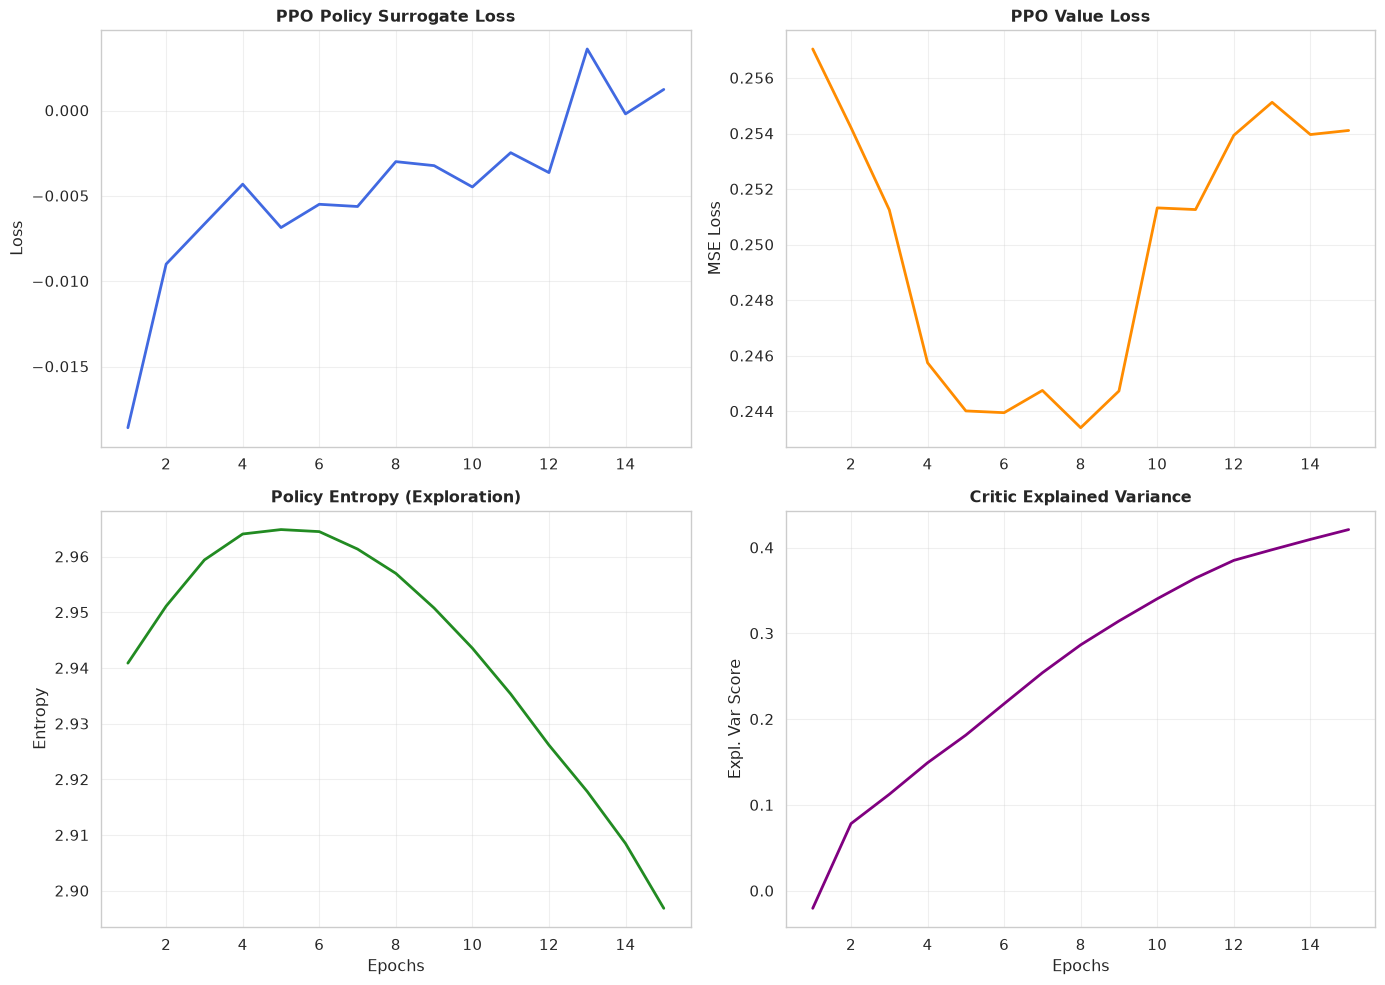

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_PPO_training_metrics(history):
    epochs = range(1, len(history["policy_loss"]) + 1)
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Policy Loss
    sns.lineplot(
        x=epochs,
        y=history["policy_loss"],
        ax=axes[0, 0],
        color="royalblue",
        linewidth=2,
    )
    axes[0, 0].set_title("PPO Policy Surrogate Loss")
    axes[0, 0].set_ylabel("Loss")

    # Value Loss
    sns.lineplot(
        x=epochs,
        y=history["value_loss"],
        ax=axes[0, 1],
        color="darkorange",
        linewidth=2,
    )
    axes[0, 1].set_title("PPO Value Loss")
    axes[0, 1].set_ylabel("MSE Loss")

    # Entropy
    sns.lineplot(
        x=epochs, y=history["entropy"], ax=axes[1, 0], color="forestgreen", linewidth=2
    )
    axes[1, 0].set_title("Policy Entropy (Exploration)")
    axes[1, 0].set_ylabel("Entropy")
    axes[1, 0].set_xlabel("Epochs")

    # Explained Variance
    sns.lineplot(
        x=epochs,
        y=history["explained_variance"],
        ax=axes[1, 1],
        color="purple",
        linewidth=2,
    )
    axes[1, 1].set_title("Critic Explained Variance")
    axes[1, 1].set_ylabel("Expl. Var Score")
    axes[1, 1].set_xlabel("Epochs")

    plt.tight_layout()
    plt.savefig(
        "./plots/PPO_Training_Metrics.pdf", format="pdf", dpi=1200, bbox_inches="tight"
    )
    plt.show()


plot_PPO_training_metrics(training_history)


## Explainable AI (XRL) Generation


### Local Explanations via SHAP (Step-by-Step Inference)


#### PyTorch Model Wrapper for SHAP


In [27]:
# SHAP requires a model that takes an input tensor and returns a single output tensor.
# Since our Dueling Network returns (Q, V, A), we wrap it to only return the Action stream (A).
class ActionStreamWrapper(nn.Module):
    def __init__(self, PPO_model):
        super(ActionStreamWrapper, self).__init__()
        self.model = PPO_model

    def forward(self, x):
        # PPO returns (mean, std, value). We only need the mean action for SHAP.
        action_mean, _, _ = self.model(x)
        return action_mean


action_model = ActionStreamWrapper(PPO_model).to(device)
action_model.eval()

ActionStreamWrapper(
  (model): PPOActorCritic(
    (shared_layers): Sequential(
      (0): Linear(in_features=46, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (5): ReLU()
    )
    (actor_mean): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=2, bias=True)
    )
    (critic): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

#### Prepare Background and Test Data


In [28]:
print("Preparing background distributions for SHAP...")

# SHAP calculates marginal contributions by comparing predictions against a "baseline" background.
# We sample 200 random states from our normalized State matrix (S_matrix) as the background.
rng = np.random.default_rng(42)
# no_of_random_states = int(input("Enter the number of random states:"))
# background_indices = rng.choice(S_matrix.shape[0], size=no_of_random_states, replace=False)
background_indices = rng.choice(S_matrix.shape[0], size=200, replace=False)
background_tensor = torch.tensor(S_matrix[background_indices], dtype=torch.float32).to(
    device
)

# Select a few specific test cases to explain (e.g., the first 5 transactions)
# transaction_cases = int(input("Enter the number of transactions:"))
# test_indices = np.arange(transaction_cases)
test_indices = np.arange(5)
test_tensor = torch.tensor(S_matrix[test_indices], dtype=torch.float32).to(device)

print("Preparing background distributions for SHAP completed successfully...")

Preparing background distributions for SHAP...
Preparing background distributions for SHAP completed successfully...


#### Initialize GradientExplainer & Compute SHAP


In [29]:
import shap

print("Initializing SHAP GradientExplainer...")
# GradientExplainer is highly stable for continuous PyTorch networks
explainer = shap.GradientExplainer(action_model, background_tensor)

print("Calculating SHAP values for test instances...")
# shap_values will be a list of arrays: [shap_values_for_action_0, shap_values_for_action_1]
shap_values = explainer.shap_values(test_tensor)

# Ensure the output format matches expectations (List of arrays for each action dimension)
if not isinstance(shap_values, list):
    # Depending on SHAP version, it might return a single tensor (batch, features, actions)
    # We slice it into a list for standard processing: [Price Action, Reorder Action]
    shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

print("\nSHAP values successfully computed.")

Initializing SHAP GradientExplainer...
Calculating SHAP values for test instances...

SHAP values successfully computed.


#### Visualizing Local Explanations



Generating Local Explanation for Action: Price per Unit (sold) (Transaction #0)


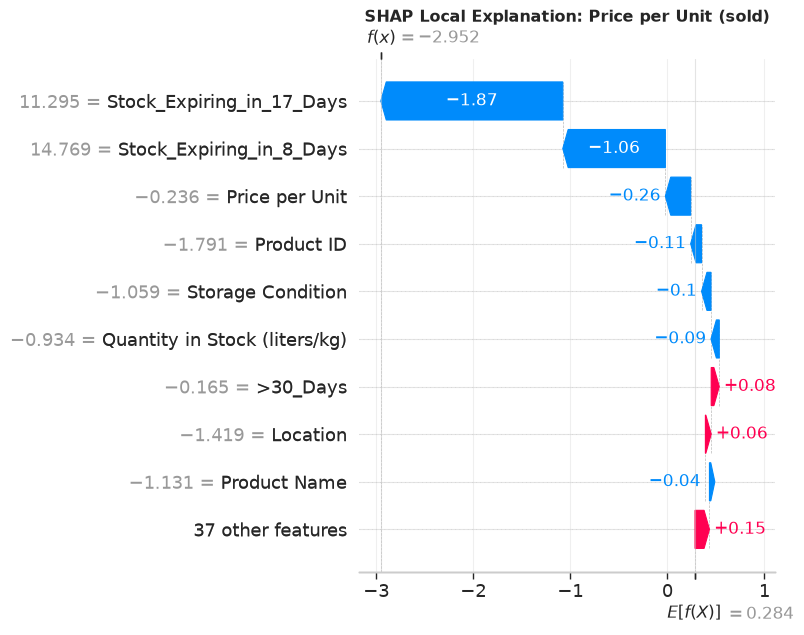


Generating Local Explanation for Action: Reorder Quantity (liters/kg) (Transaction #0)


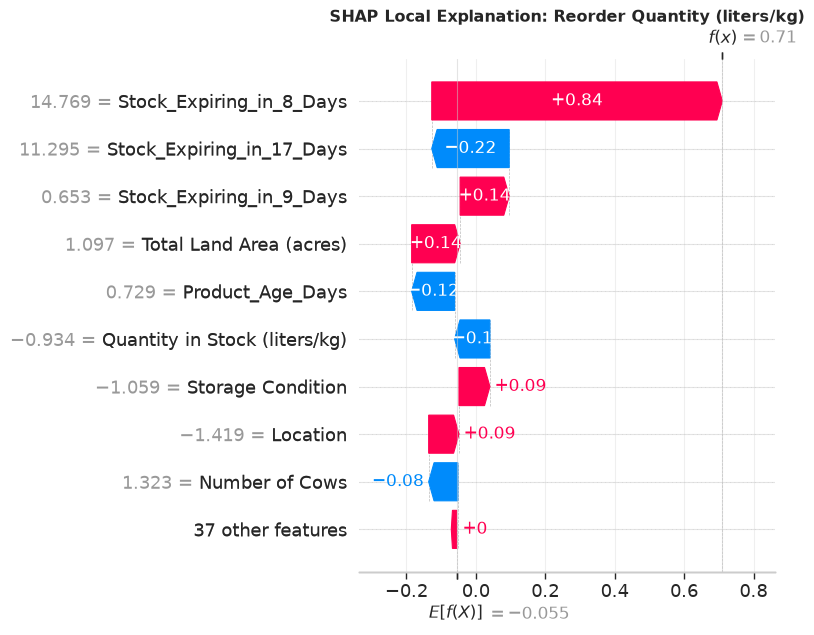

In [30]:
# We want to explain the agent's decision for a specific transaction (e.g., Transaction Index 0)
# INSTANCE_IDX = int(input("Enter the Transaction ID:"))
INSTANCE_IDX = 0

action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(
        f"\nGenerating Local Explanation for Action: {action_name} (Transaction #{INSTANCE_IDX})"
    )

    # Extract the base value (expected average output) and the SHAP values for this specific instance
    # GradientExplainer doesn't explicitly store expected_value identically to DeepExplainer, but we can calculate the mean output of the background to use as the base value.
    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        base_value = background_outputs[:, action_idx].mean().item()

    instance_shap_values = shap_values[action_idx][INSTANCE_IDX]
    instance_feature_values = S_matrix[INSTANCE_IDX]

    # Create an Explanation object for the waterfall plot
    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=base_value,
        data=instance_feature_values,
        feature_names=state_cols,
    )

    # Generate and display the Waterfall Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Local Explanation: {action_name}")
    shap.waterfall_plot(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

#### Summary Profile



Generating Global Summary for 'Price per Unit (sold)' across test batch...


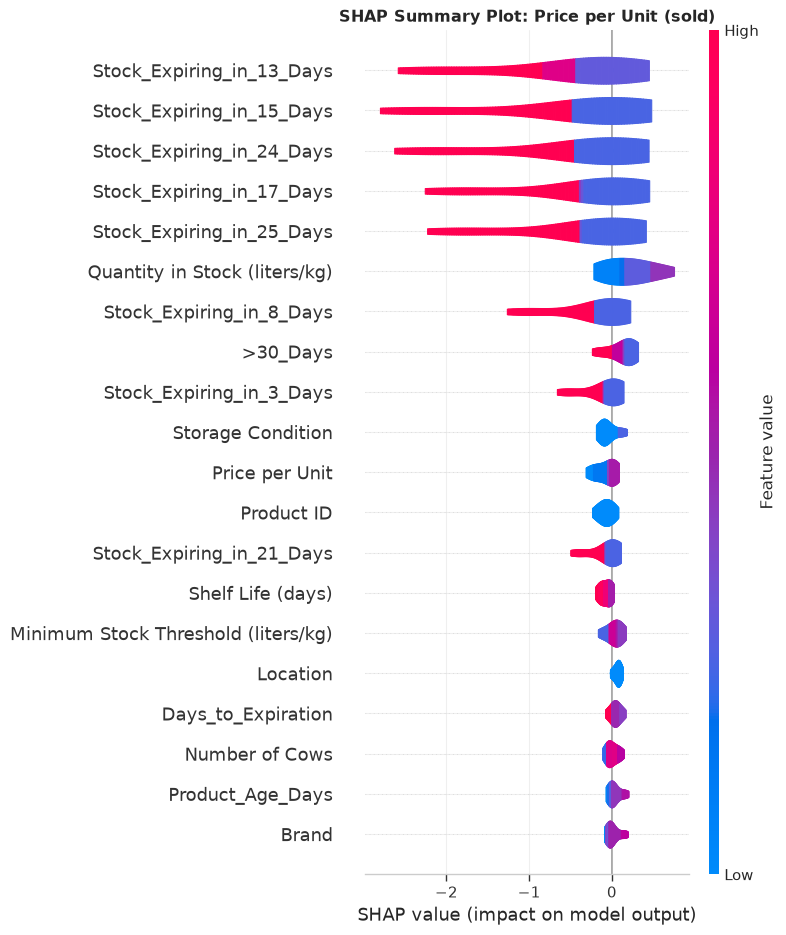

In [31]:
print("\nGenerating Global Summary for 'Price per Unit (sold)' across test batch...")
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot: {action_names[0]}")
shap.summary_plot(
    shap_values[0],
    test_tensor.cpu().numpy(),
    feature_names=state_cols,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Global Explanations via Symbolic Decision Trees


#### Generate RL Agent Predictions for the Entire Dataset


In [32]:
print("Generating agent predictions to train the surrogate...")
with torch.no_grad():
    # Push the entire scaled state matrix through the PPO Network
    S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)

    # PPO returns (action_mean, action_std, state_value)
    # We extract action_mean (the first element)
    A_pred_scaled, _, _ = PPO_model(S_tensor)

    A_pred_scaled = A_pred_scaled.cpu().numpy()

# Inverse transform the actions to get real-world values (Price in INR, Reorder in Liters/kg)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)
print("Generating agent predictions to train the surrogate successfully...")

Generating agent predictions to train the surrogate...
Generating agent predictions to train the surrogate successfully...


#### Train the Symbolic Surrogate Models


In [33]:
from sklearn.tree import DecisionTreeRegressor

print("Training Surrogate Decision Trees on unscaled features...")
# We use the raw dataframe features so the thresholds are human-readable
X_raw = rl_df_final[state_cols]

# We constrain the tree depth (max_depth=3) to ensure "Compactness" and "Cognitive Load"
# stay manageable for domain experts, avoiding a 20-level deep unreadable mess.
dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_price.fit(X_raw, A_pred_real[:, 0])

dt_reorder = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reorder.fit(X_raw, A_pred_real[:, 1])
print("Training Surrogate Decision Trees on unscaled features successfully...")

Training Surrogate Decision Trees on unscaled features...
Training Surrogate Decision Trees on unscaled features successfully...


#### Extract Human-Readable IF-THEN Rules


In [34]:
from sklearn.tree import export_text, plot_tree

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)")
print("-" * 60)
rules_price = export_text(dt_price, feature_names=list(X_raw.columns))
print(rules_price)

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: REORDER QUANTITY")
print("-" * 60)
rules_reorder = export_text(dt_reorder, feature_names=list(X_raw.columns))
print(rules_reorder)


------------------------------------------------------------
GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)
------------------------------------------------------------
|--- Price per Unit <= 70.94
|   |--- Product ID <= 10.00
|   |   |--- Quantity in Stock (liters/kg) <= 420.11
|   |   |   |--- value: [62.47]
|   |   |--- Quantity in Stock (liters/kg) >  420.11
|   |   |   |--- value: [43.83]
|   |--- Product ID >  10.00
|   |   |--- >30_Days <= 442.43
|   |   |   |--- value: [28.38]
|   |   |--- >30_Days >  442.43
|   |   |   |--- value: [15.94]
|--- Price per Unit >  70.94
|   |--- Product ID <= 10.00
|   |   |--- >30_Days <= 51.92
|   |   |   |--- value: [76.03]
|   |   |--- >30_Days >  51.92
|   |   |   |--- value: [96.73]
|   |--- Product ID >  10.00
|   |   |--- >30_Days <= 644.39
|   |   |   |--- value: [35.12]
|   |   |--- >30_Days >  644.39
|   |   |   |--- value: [16.43]


------------------------------------------------------------
GLOBAL STRATEGY RULES: REORDER QUANTITY
---

#### Evaluate Surrogate Fidelity ($R^2$ Score)


In [35]:
# Fidelity measures how accurately the simple Decision Tree mimics the complex PyTorch model.
score_price = dt_price.score(X_raw, A_pred_real[:, 0])
score_inv = dt_reorder.score(X_raw, A_pred_real[:, 1])

print("\nSurrogate Fidelity Check (R^2 Score):")
print(f"-> Pricing Strategy Tree Fidelity: {score_price:.4f}")
print(f"-> Reorder Strategy Tree Fidelity: {score_inv:.4f}")

if score_price < 0.70 or score_inv < 0.70:
    print(
        "\n* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3)."
    )
    print(
        "  To increase fidelity, increase max_depth, though this will reduce human interpretability."
    )


Surrogate Fidelity Check (R^2 Score):
-> Pricing Strategy Tree Fidelity: 0.3989
-> Reorder Strategy Tree Fidelity: 0.1406

* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3).
  To increase fidelity, increase max_depth, though this will reduce human interpretability.


#### Visualizing the Strategy Tree



Generating Decision Tree Visualization for Pricing Strategy...


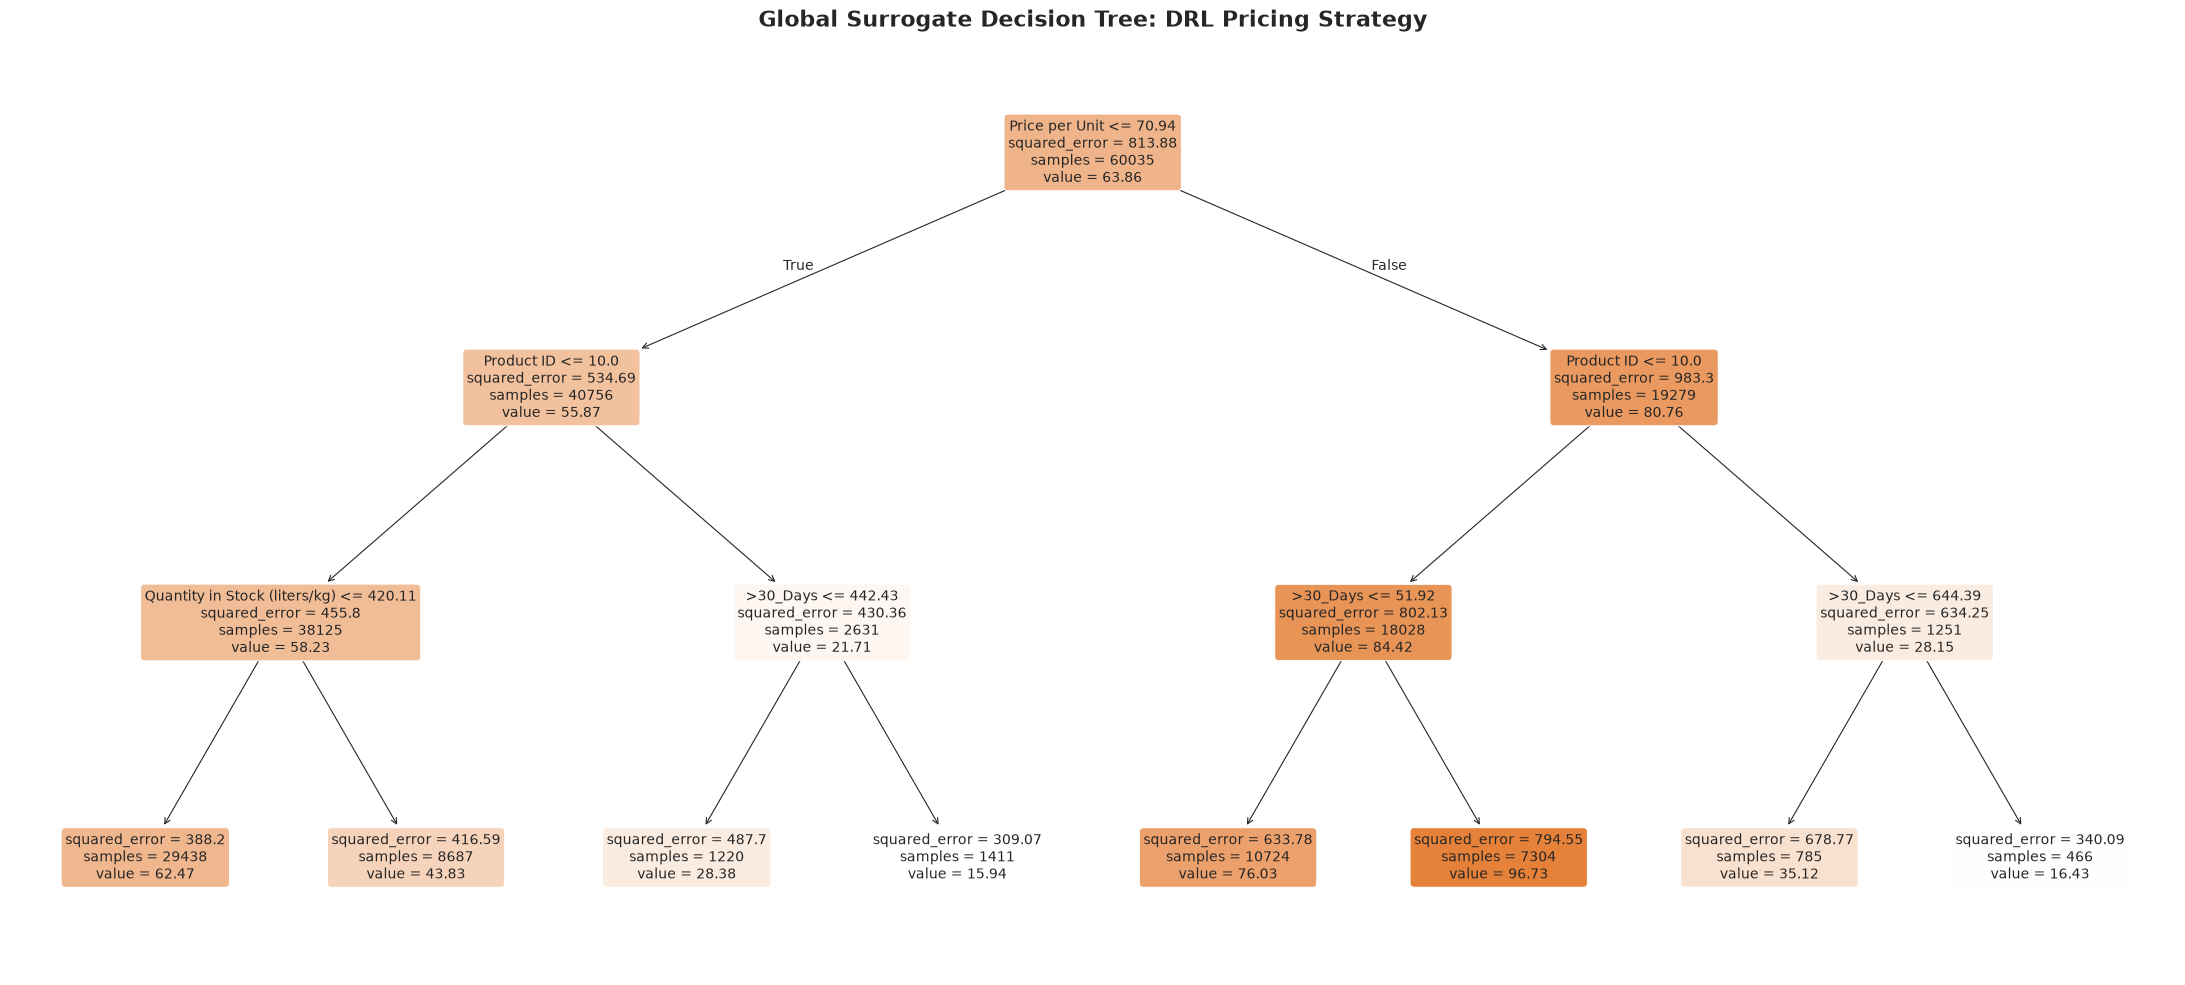

In [36]:
print("\nGenerating Decision Tree Visualization for Pricing Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_price,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Pricing Strategy", fontsize=16)
plt.tight_layout()
plt.show()


Generating Decision Tree Visualization for Reordering Strategy...


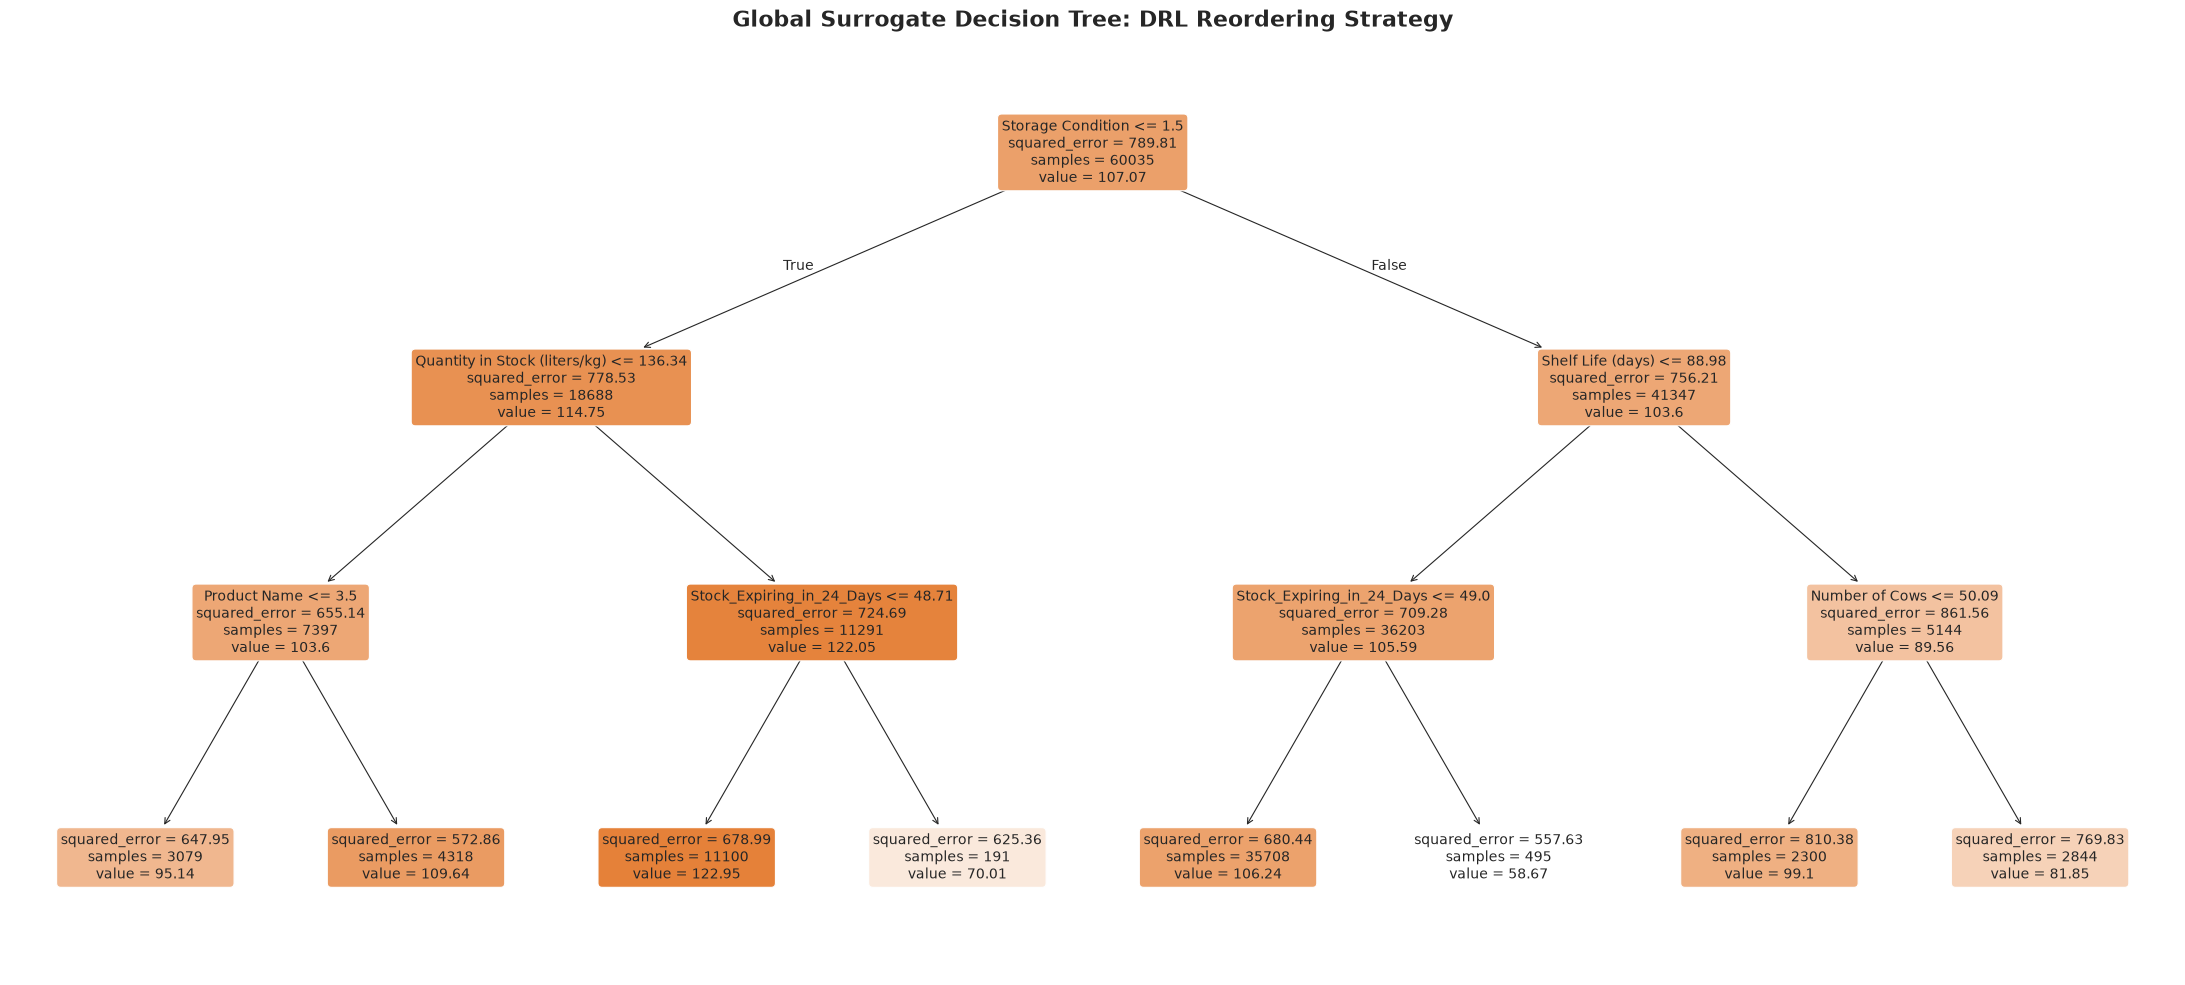

In [37]:
print("\nGenerating Decision Tree Visualization for Reordering Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_reorder,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Reordering Strategy", fontsize=16)
plt.tight_layout()
plt.show()

### Reward Decomposition (Post-Hoc Financial Surrogate)


#### Prepare Data for the Reward Surrogate


In [38]:
print("Preparing State-Action paired data...")
# We use the historical states and the historical actions to teach the surrogate how the environment reacts
X_hist = np.hstack([S_matrix, A_matrix])
# Target variables: The 4 distinct financial sub-rewards calculated in Step 1.3
Y_hist = rl_df_final[
    ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
].values

# We combine the states with the Agent's predicted actions to evaluate what the agent expects to happen when it executes its policy.
X_agent_policy = np.hstack([S_matrix, A_pred_scaled])
feature_names_extended = state_cols + action_cols
print("Preparing State-Action paired data successfully...")

Preparing State-Action paired data...
Preparing State-Action paired data successfully...


#### Train the Multi-Output Reward Surrogate


In [39]:
from sklearn.ensemble import RandomForestRegressor

print("Training Multi-Output Random Forest Surrogate for Reward Decomposition...")
# The Random Forest maps (State + Action) -> Financial Sub-Rewards
reward_surrogate = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
reward_surrogate.fit(X_hist, Y_hist)
print(
    "Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully..."
)

Training Multi-Output Random Forest Surrogate for Reward Decomposition...
Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully...


#### Predict Sub-Rewards for the Agent's Policy


In [40]:
print("Decomposing Agent's Expected Rewards...")
Y_agent_expected = reward_surrogate.predict(X_agent_policy)
print("Decomposing Agent's Expected Rewards successfully...")

Decomposing Agent's Expected Rewards...
Decomposing Agent's Expected Rewards successfully...


#### Visualizing Reward Decomposition for a Specific Transaction


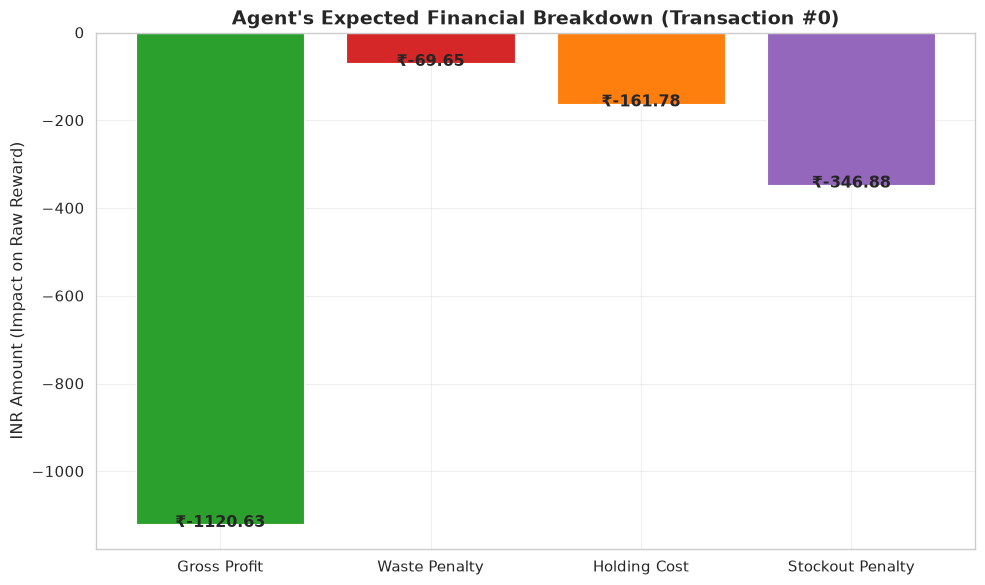

In [41]:
# INSTANCE_IDX = 0
# INSTANCE_IDX = int(input("Enter the Transaction ID:"))
sub_rewards = Y_agent_expected[INSTANCE_IDX]

labels = ["Gross Profit", "Waste Penalty", "Holding Cost", "Stockout Penalty"]
# Gross profit is a positive gain. Penalties are negative impacts to the total reward.
values = [sub_rewards[0], -sub_rewards[1], -sub_rewards[2], -sub_rewards[3]]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1.2)
plt.title(
    f"Agent's Expected Financial Breakdown (Transaction #{INSTANCE_IDX})", fontsize=14
)
plt.ylabel("INR Amount (Impact on Raw Reward)")

# Add text labels on the bars
for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (5 if v > 0 else -15),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis: Isolating a Specific Objective (Waste Penalty)



Applying SHAP to explain how the Agent controls the 'Waste Penalty' Objective...


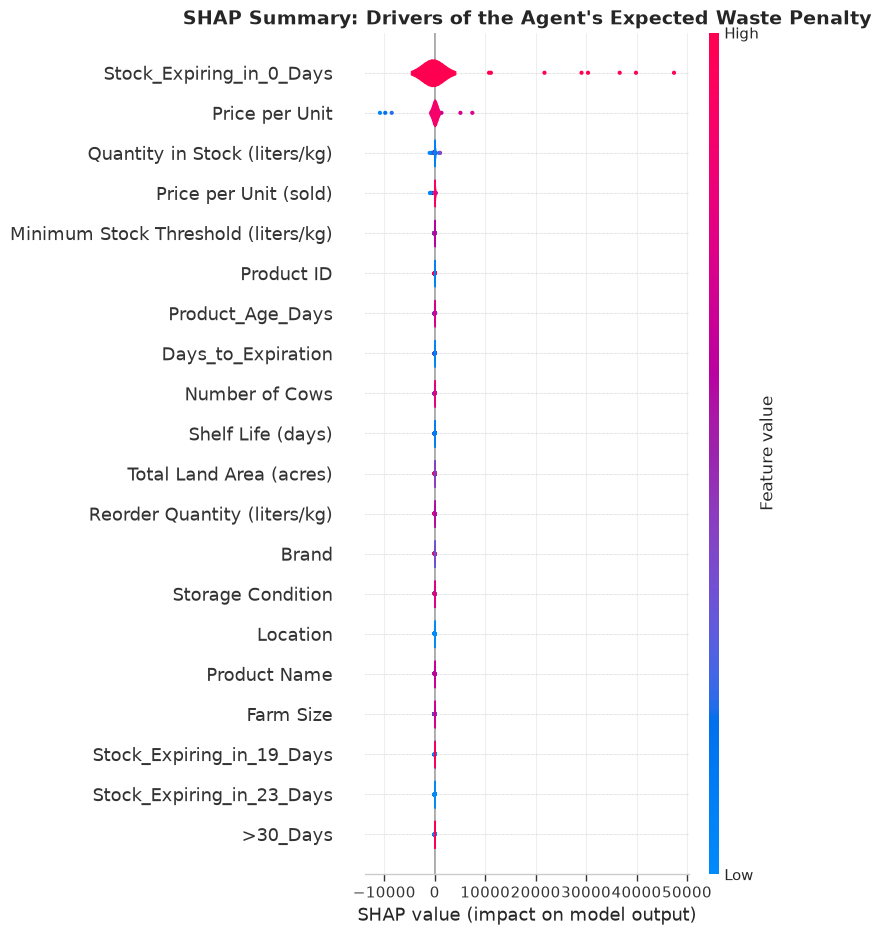

In [42]:
print(
    "\nApplying SHAP to explain how the Agent controls the 'Waste Penalty' Objective..."
)

# Explain the Random Forest model using TreeExplainer
tree_explainer = shap.TreeExplainer(reward_surrogate)

# We explain a subset of 200 instances to save computation time
# no_of_instances = int(input("Enter the number of instances:"))
# X_explain = X_agent_policy[:no_of_instances]
X_explain = X_agent_policy[:200]
shap_values_rf = tree_explainer.shap_values(X_explain)

# Safely extract the SHAP values for the second output (Waste_Penalty)
# based on the SHAP library version installed.
if isinstance(shap_values_rf, list):
    # Returns a list of arrays
    waste_shap_values = shap_values_rf[1]
else:
    # Returns a 3D tensor of shape (samples, features, outputs)
    waste_shap_values = shap_values_rf[:, :, 1]

# Generate and display the summary plot
plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: Drivers of the Agent's Expected Waste Penalty", fontsize=14)
shap.summary_plot(
    waste_shap_values,
    X_explain,
    feature_names=feature_names_extended,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

## Post-Hoc XAI Evaluation & Validation


### Post-Hoc Fidelity Baseline Testing


#### Global Fidelity vs. Interpretability Trade-Off


Evaluating Global Surrogate Fidelity across explanation complexities...


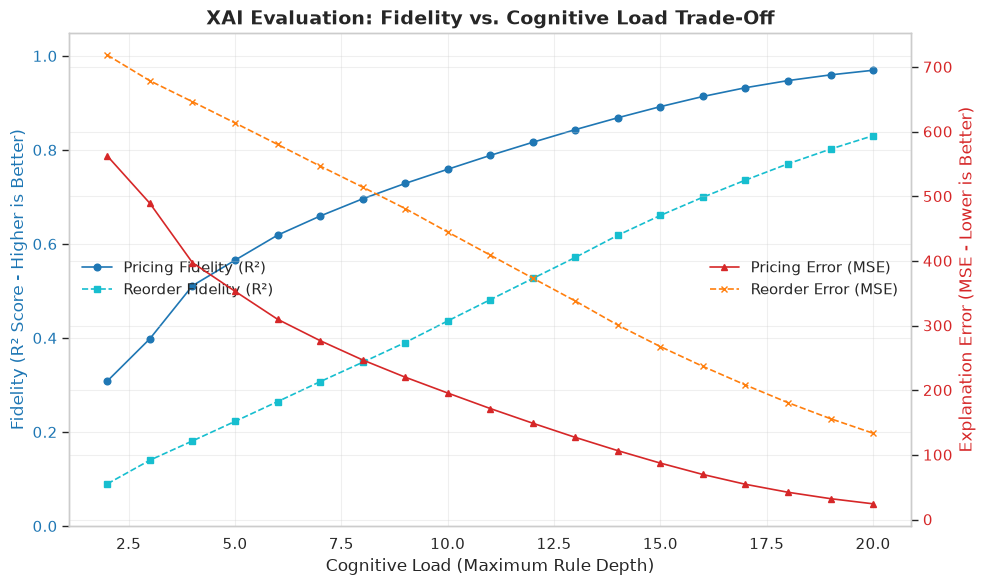

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

print("Evaluating Global Surrogate Fidelity across explanation complexities...")

# We will test Decision Trees of varying depths (from 2 to 15) to quantify the trade-off
# between Cognitive Load (Tree Depth) and Fidelity (R^2 & MSE).
depths = range(2, 21)
fidelity_r2_price = []
fidelity_r2_reorder = []
mse_price = []
mse_reorder = []

X_raw = rl_df_final[state_cols]
# A_pred_real is the DRL agent's actual continuous actions
y_price = A_pred_real[:, 0]
y_reorder = A_pred_real[:, 1]

for d in depths:
    # Train proxies for Pricing
    dt_p = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_p.fit(X_raw, y_price)
    preds_p = dt_p.predict(X_raw)
    fidelity_r2_price.append(r2_score(y_price, preds_p))
    mse_price.append(mean_squared_error(y_price, preds_p))

    # Train proxies for Reordering
    dt_r = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_r.fit(X_raw, y_reorder)
    preds_r = dt_r.predict(X_raw)
    fidelity_r2_reorder.append(r2_score(y_reorder, preds_r))
    mse_reorder.append(mean_squared_error(y_reorder, preds_r))

# Plotting the Trade-off Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
color2 = "tab:cyan"
ax1.set_xlabel("Cognitive Load (Maximum Rule Depth)", fontsize=12)
ax1.set_ylabel("Fidelity (R² Score - Higher is Better)", color=color1, fontsize=12)
ax1.plot(
    depths, fidelity_r2_price, marker="o", label="Pricing Fidelity (R²)", color=color1
)
ax1.plot(
    depths,
    fidelity_r2_reorder,
    marker="s",
    linestyle="--",
    label="Reorder Fidelity (R²)",
    color=color2,
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim((0, 1.05))
ax1.legend(loc="center left")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color3 = "tab:red"
color4 = "tab:orange"
ax2.set_ylabel("Explanation Error (MSE - Lower is Better)", color=color3, fontsize=12)
ax2.plot(depths, mse_price, marker="^", label="Pricing Error (MSE)", color=color3)
ax2.plot(
    depths,
    mse_reorder,
    marker="x",
    linestyle="--",
    label="Reorder Error (MSE)",
    color=color4,
)
ax2.tick_params(axis="y", labelcolor=color3)
ax2.legend(loc="center right")

plt.title("XAI Evaluation: Fidelity vs. Cognitive Load Trade-Off", fontsize=14)
fig.tight_layout()
plt.savefig(
    "./plots/PPO_Fidelity_vs_Cognitive_Load.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

#### Local Fidelity (SHAP Completeness Axiom)


In [44]:
print("\nEvaluating Local Explanation Fidelity (SHAP Completeness Axiom)...")
# A faithful local explainer must strictly map: sum(SHAP) + Expected_Base_Value == Actual_Model_Output
# If this fails, the local explanation is 'leaking' information and cannot be trusted.

local_fidelity_passed = True
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(f"\nVerifying Completeness for Action: {action_name}")

    # Get baseline expected output across the SHAP background distribution
    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        expected_val = background_outputs[:, action_idx].mean().item()

        # Get actual DRL agent predictions for the specific test instances
        actual_preds = action_model(test_tensor)[:, action_idx].cpu().numpy()

    # Get the sum of the calculated SHAP attributions for the test instances
    shap_sums = shap_values[action_idx].sum(axis=1)

    # Algebraically check Additivity: sum(SHAP) + Base = Actual Output
    for i in range(len(test_indices)):
        explanation_pred = shap_sums[i] + expected_val
        actual_pred = actual_preds[i]
        diff = abs(explanation_pred - actual_pred)

        print(
            f" Instance #{i} | Actual DRL Output: {actual_pred:.4f} | SHAP Explained Output: {explanation_pred:.4f} | Math Diff: {diff:.6f}"
        )

        # Allow a tiny float precision threshold (1e-4) due to 32-bit GPU math
        if diff > 1e-4:
            local_fidelity_passed = False

if local_fidelity_passed:
    print(
        "\n[SUCCESS] Local Fidelity Check Passed: SHAP values strictly reconstruct the DRL agent's local decisions."
    )
else:
    print(
        "\n[WARNING] Local Fidelity Check Failed: SHAP explanations do not sum to the DRL output. The approximation is leaking information."
    )


Evaluating Local Explanation Fidelity (SHAP Completeness Axiom)...

Verifying Completeness for Action: Price per Unit (sold)
 Instance #0 | Actual DRL Output: -3.0257 | SHAP Explained Output: -2.9524 | Math Diff: 0.073256
 Instance #1 | Actual DRL Output: -2.0341 | SHAP Explained Output: -2.0439 | Math Diff: 0.009767
 Instance #2 | Actual DRL Output: -1.9760 | SHAP Explained Output: -1.9008 | Math Diff: 0.075269
 Instance #3 | Actual DRL Output: -1.7229 | SHAP Explained Output: -1.8035 | Math Diff: 0.080637
 Instance #4 | Actual DRL Output: -0.6057 | SHAP Explained Output: -0.5194 | Math Diff: 0.086284

Verifying Completeness for Action: Reorder Quantity (liters/kg)
 Instance #0 | Actual DRL Output: 0.6543 | SHAP Explained Output: 0.7101 | Math Diff: 0.055877
 Instance #1 | Actual DRL Output: -0.3710 | SHAP Explained Output: -0.4885 | Math Diff: 0.117503
 Instance #2 | Actual DRL Output: 0.3088 | SHAP Explained Output: 0.2188 | Math Diff: 0.089971
 Instance #3 | Actual DRL Output: 0.6

### Selectivity & Perturbation (PI / Masking)


#### Identify Top and Bottom Features from SHAP


In [45]:
# We use the absolute mean of the SHAP values for Pricing (Action Index 0) from Step 3.1
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)
sorted_feature_indices = np.argsort(mean_abs_shap)[::-1]

# Extract Top 3 Features
top_3_indices = sorted_feature_indices[:3]
top_3_features = [state_cols[i] for i in top_3_indices]
print(f"Top 3 Features identified by SHAP: \n{top_3_features}\n")

# Extract Bottom 3 Features (for Sanity Check)
bottom_3_indices = sorted_feature_indices[-3:]
bottom_3_features = [state_cols[i] for i in bottom_3_indices]

Top 3 Features identified by SHAP: 
['Stock_Expiring_in_13_Days', 'Stock_Expiring_in_15_Days', 'Stock_Expiring_in_24_Days']



#### Collinearity Check


In [46]:
print("Executing Collinearity Check...")
# We must ensure we don't unfairly penalize the XAI metric if the agent just switches to a highly correlated duplicate feature when the main one is masked.

for feat in top_3_features:
    corrs = []
    for f1, f2, val in collinear_pairs:
        if feat == f1:
            corrs.append(f2)
        elif feat == f2:
            corrs.append(f1)

    if corrs:
        print(
            f" [!] WARNING: '{feat}' is highly correlated with {corrs}. "
            f"Masking it might trigger the agent to use the correlated proxy."
        )
    else:
        print(f" [OK] '{feat}' is independent. No collinearity detected.")

Executing Collinearity Check...
 [OK] 'Stock_Expiring_in_13_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_15_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_24_Days' is independent. No collinearity detected.


#### Permutation Importance / Masking Evaluation


In [47]:
print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    """
    Passes the state through the DRL agent to get actions,
    then passes (State, Action) through the Reward Surrogate to get the expected financial return.
    """
    with torch.no_grad():
        # Action_model now returns a single tensor, so we no longer unpack it with commas.
        # (Alternatively, you could use: pred_actions, _, _ = PPO_model(state_tensor))
        pred_actions = action_model(state_tensor)

    # Combine state and actions for the reward surrogate
    X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
    sub_rewards = reward_surrogate.predict(X_eval)

    # Raw Reward = Gross Profit - Waste Penalty - Holding Cost - Stockout Penalty
    raw_rewards = (
        sub_rewards[:, 0] - sub_rewards[:, 1] - sub_rewards[:, 2] - sub_rewards[:, 3]
    )
    return raw_rewards.mean()


# A. Calculate Baseline Expected Reward
baseline_reward = evaluate_policy_reward(test_tensor)
print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

# B. Perturb Top 3 Features (Masking)
# We mask the information by setting the scaled feature to 0.0 (the dataset mean)
perturbed_states_top = test_tensor.clone()
for idx in top_3_indices:
    perturbed_states_top[:, idx] = 0.0

degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
drop_pct_top = ((baseline_reward - degraded_reward_top) / abs(baseline_reward)) * 100
print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

# C. Perturb Bottom 3 Features (Sanity Check)
print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
perturbed_states_bottom = test_tensor.clone()
for idx in bottom_3_indices:
    perturbed_states_bottom[:, idx] = 0.0

degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
drop_pct_bottom = (
    (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
) * 100
print(f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}")
print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")


Evaluating Agent Performance Drop (Perturbation Importance)...
-> Baseline Expected Reward (Unperturbed): ₹-2682.05
-> Expected Reward (Top 3 Features Masked): ₹-2630.23
-> Performance Impact: -1.93% drop

Sanity Check: Masking Bottom 3 Features 
['Stock_Expiring_in_14_Days', 'Stock_Expiring_in_5_Days', 'Stock_Expiring_in_23_Days']...
-> Expected Reward (Bottom 3 Features Masked): ₹-2682.05
-> Performance Impact: 0.00% drop


#### Visualization of Performance Degradation


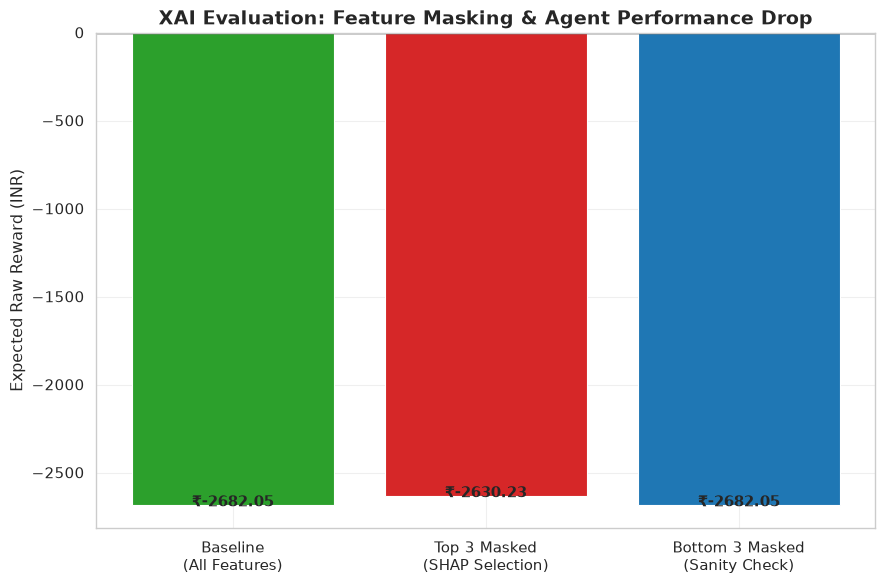

In [48]:
labels = [
    "Baseline\n(All Features)",
    "Top 3 Masked\n(SHAP Selection)",
    "Bottom 3 Masked\n(Sanity Check)",
]
values = [baseline_reward, degraded_reward_top, degraded_reward_bottom]
colors = ["#2ca02c", "#d62728", "#1f77b4"]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)
plt.title("XAI Evaluation: Feature Masking & Agent Performance Drop", fontsize=14)
plt.ylabel("Expected Raw Reward (INR)")
plt.axhline(0, color="black", linewidth=1)

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (10 if v > 0 else -30),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### Stability & Robustness Profiling (Lipschitz Continuity)


#### Generate Local Perturbations (Noise Injection)


In [49]:
print("Generating 100 near-identical state transitions...")
NUM_SAMPLES = 100
# INSTANCE_IDX = 0
ACTION_IDX = 0  # We evaluate the pricing action

# Extract the base state
base_state = S_matrix[INSTANCE_IDX]

# Inject small Gaussian noise (std=0.01) to simulate tiny environmental fluctuations
# Because S_matrix is StandardScaled, 0.01 represents a 1% standard deviation shift
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=0.01, size=(NUM_SAMPLES, STATE_DIM))
perturbed_states = base_state + noise

# Ensure the original state is included as the reference at index 0
perturbed_states[0] = base_state
perturbed_tensor = torch.tensor(perturbed_states, dtype=torch.float32).to(device)

Generating 100 near-identical state transitions...


#### Extract SHAP Explanations for Perturbed States


In [50]:
print("Calculating SHAP values for perturbed states...")
# We use the GradientExplainer initialized in Step 3.1
shap_values_perturbed = explainer.shap_values(perturbed_tensor)

# Format handling for different SHAP versions
if isinstance(shap_values_perturbed, list):
    shap_action_perturbed = shap_values_perturbed[ACTION_IDX]
else:
    shap_action_perturbed = shap_values_perturbed[:, :, ACTION_IDX]

# Base SHAP explanation
base_shap = shap_action_perturbed[0]

Calculating SHAP values for perturbed states...


#### Calculate Lipschitz Continuity and Variance


In [51]:
from scipy.spatial.distance import cdist

print("Calculating Lipschitz constants and feature-wise variance...")

# Calculate Euclidean distance between base state and perturbed states (Dx)
# Add a tiny epsilon (1e-9) to prevent division by zero for the base state itself
dx = cdist([base_state], perturbed_states, metric="euclidean")[0] + 1e-9

# Calculate Euclidean distance between base SHAP explanation and perturbed SHAP explanations (De)
de = cdist([base_shap], shap_action_perturbed, metric="euclidean")[0]

# Lipschitz constant is the maximum ratio of change in explanation to change in input
lipschitz_ratios = de / dx
local_lipschitz_constant = np.max(
    lipschitz_ratios[1:]
)  # Ignore index 0 (the base state itself)

# Calculate the variance of the SHAP values for each feature across the 100 samples
shap_variances = np.var(shap_action_perturbed, axis=0)

print("\nStability Metrics:")
print("-" * 60)
print(f"-> Local Lipschitz Constant (L): {local_lipschitz_constant:.4f}")
if local_lipschitz_constant < 5.0:
    print(
        "   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy."
    )
else:
    print(
        "   [WARNING] High Lipschitz constant. The explanations are fragile to noise."
    )

Calculating Lipschitz constants and feature-wise variance...

Stability Metrics:
------------------------------------------------------------
-> Local Lipschitz Constant (L): 17.5694
   [WARNING] High Lipschitz constant. The explanations are fragile to noise.


#### Visualization of XAI Robustness



Generating Robustness Profile Visualizations...


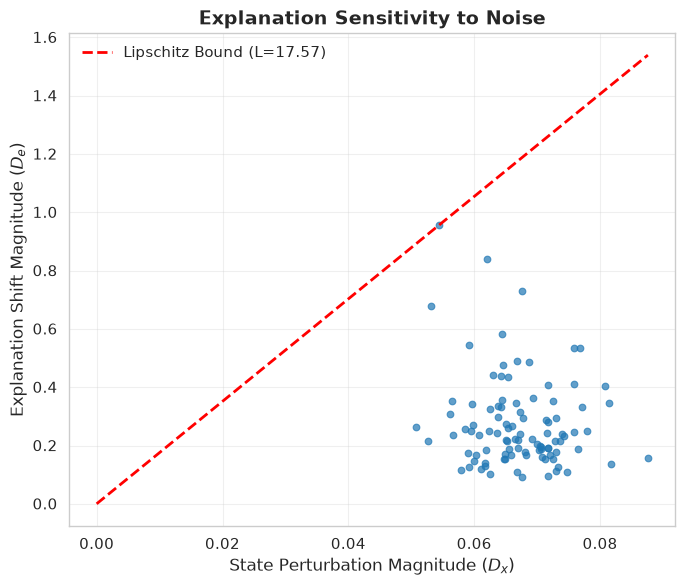

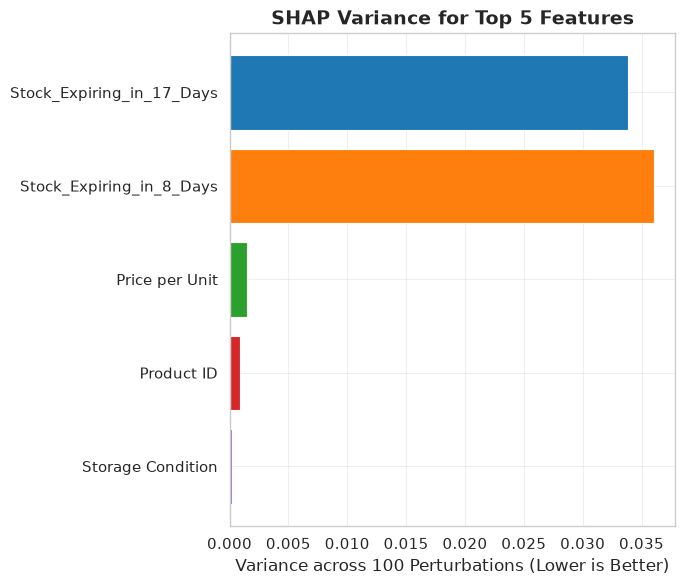

In [52]:
print("\nGenerating Robustness Profile Visualizations...")

# Plot 1: Explanation Sensitivity to Noise
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

ax.scatter(dx[1:], de[1:], alpha=0.7, color="#1f77b4")

ax.set_title("Explanation Sensitivity to Noise", fontsize=14)
ax.set_xlabel(r"State Perturbation Magnitude ($D_x$)", fontsize=12)
ax.set_ylabel(r"Explanation Shift Magnitude ($D_e$)", fontsize=12)
ax.grid(alpha=0.3)

# Lipschitz bounding line
x_vals = np.linspace(0, np.max(dx), 100)
y_vals = local_lipschitz_constant * x_vals

ax.plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Lipschitz Bound (L={local_lipschitz_constant:.2f})",
)

ax.legend()

plt.tight_layout()
plt.savefig(
    "./plots/PPO_Explanation_Sensitivity_to_Noise.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# Plot 2: SHAP Variance of Top Features
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

# Top 5 most important features
top_5_indices = np.argsort(np.abs(base_shap))[::-1][:5]
top_5_features = [state_cols[i] for i in top_5_indices]
top_5_variances = shap_variances[top_5_indices]

ax.barh(
    top_5_features[::-1],
    top_5_variances[::-1],
    color=["#9467bd", "#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"],
)

ax.set_title("SHAP Variance for Top 5 Features", fontsize=14)
ax.set_xlabel(
    "Variance across 100 Perturbations (Lower is Better)",
    fontsize=12,
)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./plots/PPO_SHAP_Variance_Top5_Features.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Architectural Metric Summary


In [53]:
import pandas as pd

PPO_data = {
    "Average Reward": training_history["avg_reward"][-1],
    "Policy Loss": training_history["policy_loss"][-1],
    "Value Loss": training_history["value_loss"][-1],
    "MAE": (eval_metrics["Pricing"]["MAE"] + eval_metrics["Reordering"]["MAE"]) / 2,
    "RMSE": (eval_metrics["Pricing"]["RMSE"] + eval_metrics["Reordering"]["RMSE"]) / 2,
    "R²": (eval_metrics["Pricing"]["R2"] + eval_metrics["Reordering"]["R2"]) / 2,
    "Pricing Accuracy": f"{eval_metrics['Pricing']['Accuracy']:.2f}%",
    "Reordering Accuracy": f"{eval_metrics['Reordering']['Accuracy']:.2f}%",
    "Overall DRL Accuracy": f"{overall_accuracy:.2f}%",
    "Training Time": f"{training_time * 60:.2f} sec",
    "Pricing Strategy Tree Fidelity (Depth=3)": f"{score_price * 100:.2f}%",
    "Reorder Strategy Tree Fidelity (Depth=3)": f"{score_inv * 100:.2f}%",
    "Baseline Expected Reward (Unperturbed)": f"₹{baseline_reward:.2f}",
    "Expected Reward (Top 3 Features Masked)": f"₹{degraded_reward_top:.2f}",
    "Expected Reward (Bottom 3 Features Masked):": f"₹{degraded_reward_bottom:.2f}",
    "Performance Impact (Top 3 Features Masked)": f"{drop_pct_top:.2f}%",
    "Performance Impact (Bottom 3 Features Masked)": f"{drop_pct_bottom:.2f}%",
    "Lipschitz Constant": local_lipschitz_constant,
}

PPO_df = pd.DataFrame([PPO_data], index=["PPO"]).T
PPO_df.to_csv("./results/PPO_df.csv", index=True)
PPO_df

,PPO
Average Reward,-0.048919
Policy Loss,0.001238
Value Loss,0.254112
MAE,0.94712
RMSE,1.147969
R²,-0.31789
Pricing Accuracy,69.11%
Reordering Accuracy,67.15%
Overall DRL Accuracy,68.13%
Training Time,54.13 sec
